In [1]:
import os,sys
import torchvision
import argparse
import torch
import tqdm

/nfs_home/bowen/cv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
slurm_rt="/cadd_data/samba_share/from_docker/rt-detr"
sys.path.append(slurm_rt)
from src.solver.utils import output_to_smiles
os.chdir(slurm_rt)
os.getcwd()

'/cadd_data/samba_share/from_docker/rt-detr'

In [4]:

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS
from src.data import get_coco_api_from_dataset



In [5]:
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F

def image_to_tensor(image_path):
    # Open the image using PIL
    image = Image.open(image_path)
    w, h = image.size
    print("width: {}, height: {}".format(w, h))
    # Define a transform to convert the image to a tensor and normalize it
    transform = transforms.Compose([
        # transforms.Grayscale(num_output_channels=1),  # Convert to grayscale (1 channel)
        T.Resize((640, 640)),  # Resize the image to 224x224
        T.ToImageTensor(),  # Convert to Tensor (C x H x W)
        T.ConvertDtype(dtype=torch.float32)
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Optional normalization for pretrained models
    ])
    
    # Apply the transform to the image
    tensor = transform(image)
    
    return tensor,w,h


bond_labels = [13,14,15,16,17]
idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
            9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
            16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?


In [5]:
home="/home/jovyan/rt-detr"
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/checkpoint0032.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample/checkpoint0052.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{pp}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{cc}')
parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{tt}')

parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [6]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
args.gpu_device=0
cfg.device=torch.device('cuda', args.gpu_device)

In [7]:
_model=cfg.model
#postprocess need the image original size
saved_statDict=torch.load(cfg.resume)
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
current_model_dict=_model.state_dict()

postprocessor = cfg.postprocessor##RTDETRPostProcessor@@src/zoo/rtertr

Load PResNet50 state_dict


In [8]:
#loaidng trained weights

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 808 are all included in current build model keys: 808
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:808@finalLoad, all:808@buildModel, 808@pretrained. 
  loaded keys 808, skip mismatch size keys 0 (same nnName but diff dimensions)


In [9]:
# print("when training use this as valdation dataset::",
#     cfg.yaml_cfg['val_dataloader']['dataset']['img_folder'],"\n",
# cfg.yaml_cfg['val_dataloader']['dataset']['ann_file'])

# print(type(cfg.val_dataloader))#note this val_dataloader is the training config used, not used for testing 
# print(cfg.val_dataloader.dataset)

In [ ]:
# Example usage: #change thie image
image_path = '/home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/images/test/US20080113922A1_p0020_x0335_y1304_c00059.png'
tensor,w,h = image_to_tensor(image_path)
tensor=tensor.unsqueeze(0)
print(tensor.size())  # Output tensor shape (C x H x W)


width: 300, height: 300
torch.Size([1, 3, 640, 640])


In [11]:
# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print(_model.training)
    outputs = _model(tensor)
    


False


In [12]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
result_ = postprocessor(outputs, ori_size)
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}

In [13]:
x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

In [25]:
from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text
import draw_box_utils
from PIL import ImageColor
import PIL.ImageDraw as ImageDraw
import numpy as np
import src
from rdkit.Chem import Draw, AllChem


In [15]:
import importlib


In [26]:
importlib.reload(draw_box_utils)
importlib.reload(src.solver.utils)
from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text


In [65]:
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']

img_ori = Image.open(image_path).convert('RGB')
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
# predict_boxes = predict_boxes*10/3
# # 过滤掉低概率的目标
# line_thickness=2
# box_thresh=0.5
# font='arial.ttf'
# font_size=12
# idxs = np.greater(predict_scores, box_thresh)
# boxes = predict_boxes[idxs]
# classes = predict_classes[idxs]
# scores = predict_scores[idxs]

# colors = [ImageColor.getrgb(STANDARD_COLORS[cls % len(STANDARD_COLORS)]) for cls in classes]
# draw = ImageDraw.Draw(img)
# for box, cls, score, color in zip(boxes, classes, scores, colors):
#     left, top, right, bottom = box
#     # 绘制目标边界框
#     draw.line([(left, top), (left, bottom), (right, bottom),
#                 (right, top), (left, top)], width=line_thickness, fill=color)
#     # 绘制类别和概率信息
#     draw_text(draw, box.tolist(), int(cls), float(score), idx_to_labels, color, font, font_size)
# #view
# boxed_img=draw._image
boxed_img = draw_objs(img,
                         predict_boxes*10/3,
                        predict_classes,
                        predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

In [ ]:
atoms_df, bonds_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list )#NOTE, get SDF from mol_rebuit


In [67]:

opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False
img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))

In [68]:
combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
combined_img.paste(img_ori_1k, (0, 0))
combined_img.paste(boxed_img, (img_ori_1k.width, 0))
combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))

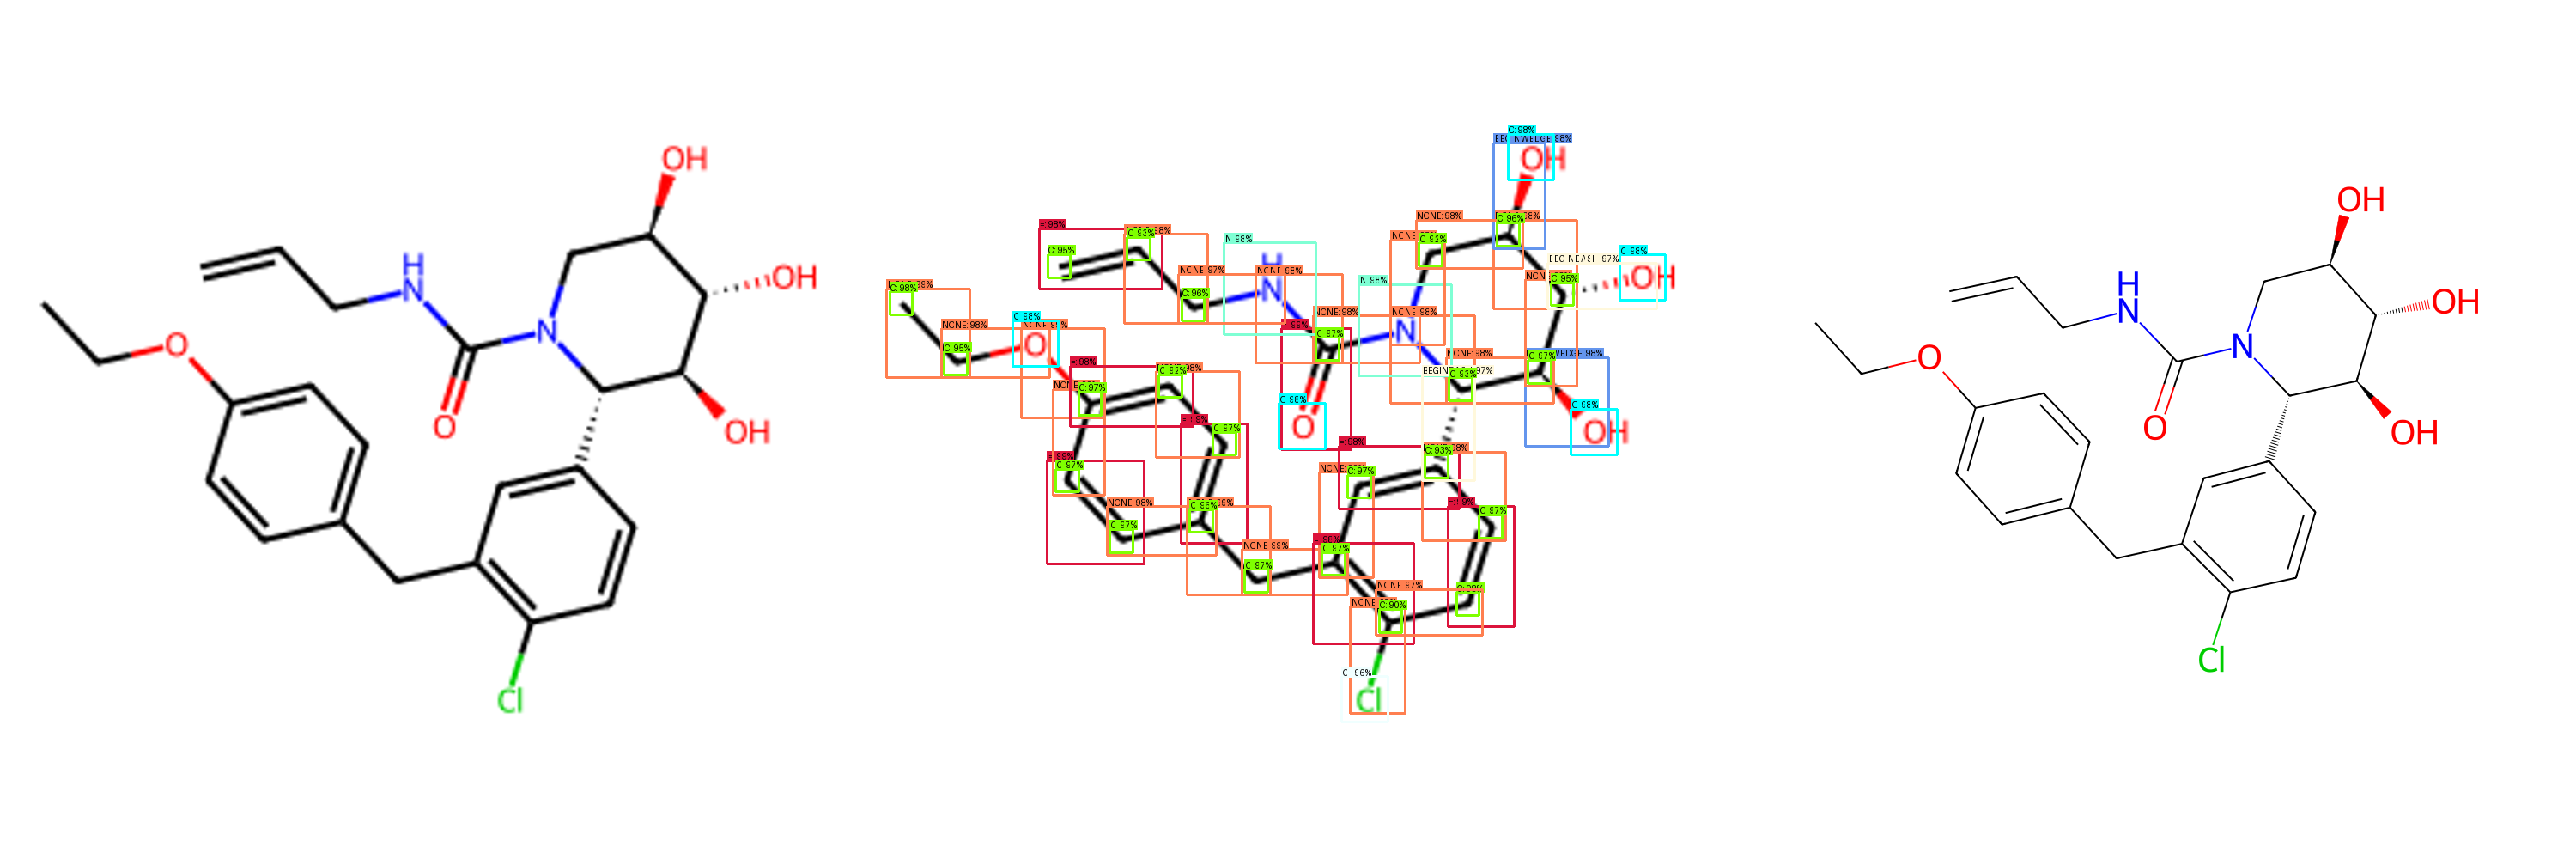

In [69]:
combined_img

In [22]:
res_smiles=[]
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result)) 

In [23]:
#prediction postprocesss 
logits, boxes = outputs['pred_logits'], outputs['pred_boxes']
scores =  torch.nn.functional.sigmoid(logits)
bbox_pred = torchvision.ops.box_convert(boxes, in_fmt='cxcywh', out_fmt='xyxy')
labels_scores = torch.nn.functional.softmax(logits,dim=-1)
labels_pred = torch.argmax(labels_scores,dim=-1)

In [24]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)